### Imputation for panel data

In [1]:
import pandas as pd

# Create a sample DataFrame representing panel data
data = {
    'Patient': ['A', 'A', 'A', 'B', 'B', 'B'],
    'Visit': [1, 2, 3, 1, 2, 3],
    'Value': [1, 2, None, 4, None, 6]
}
df = pd.DataFrame(data)

# Set the index to be a MultiIndex using 'Entity' and 'Time'
df.set_index(['Patient', 'Visit'], inplace=True)

# Forward-fill missing values within each entity
df_filled = df.ffill()

print("Original DataFrame:")
print(df)

print("\nDataFrame after forward-fill:")
print(df_filled)

Original DataFrame:
               Value
Patient Visit       
A       1        1.0
        2        2.0
        3        NaN
B       1        4.0
        2        NaN
        3        6.0

DataFrame after forward-fill:
               Value
Patient Visit       
A       1        1.0
        2        2.0
        3        2.0
B       1        4.0
        2        4.0
        3        6.0


In [2]:
df.reset_index()

,Patient,Visit,Value
0,A,1,1.0
1,A,2,2.0
2,A,3,NaN
3,B,1,4.0
4,B,2,NaN
5,B,3,6.0


In [3]:
df.sort_values(by=['Patient', 'Visit']).groupby('Patient')['Value'].bfill().reset_index()

,Patient,Visit,Value
0,A,1,1.0
1,A,2,2.0
2,A,3,NaN
3,B,1,4.0
4,B,2,6.0
5,B,3,6.0


## Excercise: Diabetes dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Path')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
os.environ['KAGGLE_USERNAME'] = 'BDA'
os.environ['KAGGLE_KEY'] = 'KGAT_3f3ceca6c3fc64f2daf6a7f63a5fd0ed'


!kaggle datasets download -d uciml/pima-indians-diabetes-database
!unzip /content/drive/MyDrive/Colab_Notebooks/BDA/pima-indians-diabetes-database.zip



Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0
pima-indians-diabetes-database.zip: Skipping, found more recently modified local copy (use --force to force download)
unzip:  cannot find or open /content/drive/MyDrive/Colab_Notebooks/BDA/pima-indians-diabetes-database.zip, /content/drive/MyDrive/Colab_Notebooks/BDA/pima-indians-diabetes-database.zip.zip or /content/drive/MyDrive/Colab_Notebooks/BDA/pima-indians-diabetes-database.zip.ZIP.


In [5]:
import pandas as pd
import numpy as np
df=pd.read_csv('./pima-indians-diabetes-database.zip')

#Let's create fake training/test sets
test_indices=df.dropna().sample(frac=0.15, random_state=42).index
train_indices=set(df.index)-set(test_indices)

df_test=df.loc[list(test_indices),:]
df=df.loc[list(train_indices),:]

#The dataset contains some features and a target variable of interest
features = ['Pregnancies',
            'Glucose',
            'BloodPressure',
            'SkinThickness',
            'Insulin',
            'BMI',
            'DiabetesPedigreeFunction',
            'Age']
target='Outcome'

df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


<Axes: >

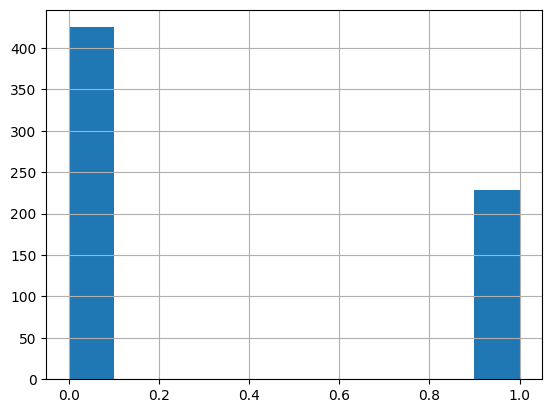

In [6]:
df['Outcome'].hist()

In [7]:
#Apparently there are no NaNs
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
#But an inspection of the dataset reveals that some variables have suspicious zero values.
#Those are NaNs (it is clearly stated if you look at the dataset documentation)
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,653.000000,653.000000,653.000000,653.000000,653.000000,653.000000,653.000000,653.000000,653.000000
mean,3.823890,120.840735,69.185299,20.287902,80.261868,31.937519,0.471908,32.856049,0.349158
std,3.372741,32.051661,18.830963,15.588254,116.176868,7.786721,0.338030,11.477537,0.477069
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.000000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,22.000000,36.000000,32.000000,0.374000,29.000000,0.000000
75%,6.000000,139.000000,80.000000,32.000000,127.000000,36.400000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [10]:
#Let's replace zeros with standard np.nan values and check how many are they

mask_missing=(df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI']] == 0)
num_missing = (mask_missing).sum()
# report the results
print(num_missing)

Glucose            5
BloodPressure     27
SkinThickness    192
Insulin          315
BMI                8
dtype: int64


In [11]:
df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI']]= df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI']].replace(0, np.nan)

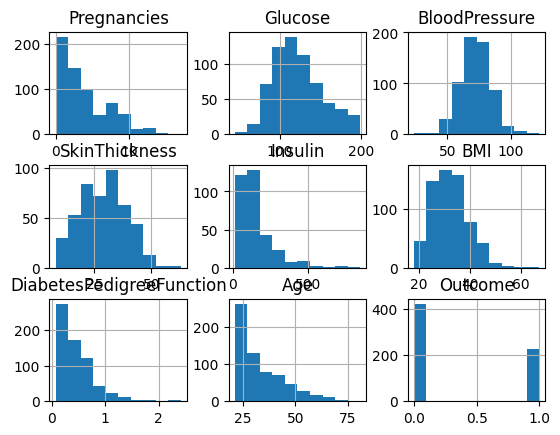

In [12]:
#What are the distribution of the variables in the dataset?

import matplotlib.pyplot as plt
df.hist()
plt.show()

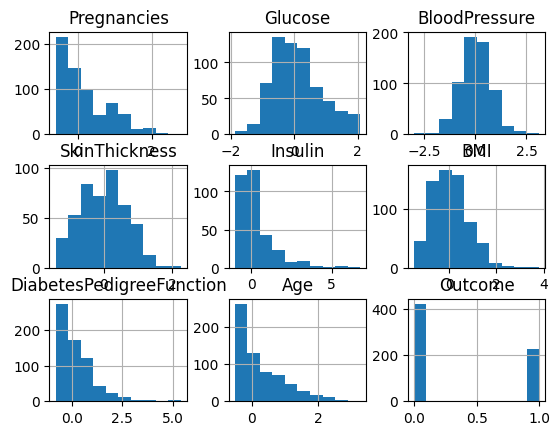

In [13]:

#As we saw, many imputation methods require features to be rescaled (knn, IterativeImputer).
#As we are going to use them, let us rescale the original features using the robust rescaler from sklearn (it subtracts the median and rescale using IQR).
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df_train=df.copy()
df_train[features] = scaler.fit_transform(df_train[features])

#If we plot the distributions again, we see that they are not distorted. Just rescaled.
df_train.hist()
plt.show()

In [14]:
df_train.shape

(653, 9)

#Excercise

## Drop rows containing nan values
* Create a dataset copy where you drop all rows containing NaN values in the feature columns
* Compare variable distribution before and after dropping cols. Is there any clear difference? Use histograms and consider adding the inputs alpha=0.5 and density=True for an easier comparison.

In [15]:
#Dropping all NaN values in the relevant features 
df_drop = df.copy()
df_drop.dropna(subset=features, inplace=True)



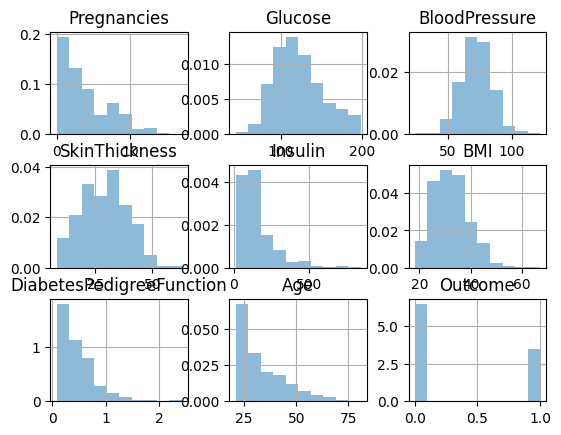

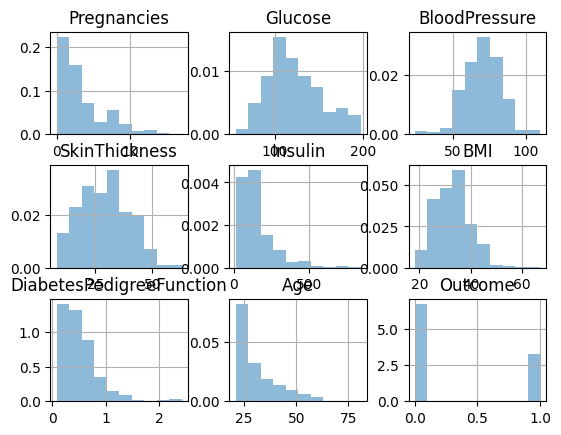

In [16]:
df.hist(alpha=0.5, density=True)
df_drop.hist(alpha=0.5, density=True)
plt.show()

#Major changes are shown in the Glucose and DiabetesPedigreeFunction features.
#Overall the distribution is not distorted, so we can use this method on this dataset.

## Simple imputation of missing values
* Choose what may be the best technique for simple imputation considering the column meaning and distribution
* Create a copy of the dataset where you use simple imputation techniques to fill missing data
* Compare variable distribution before and after imputing cols. Is there any clear difference?

In [36]:
#Since all the feature presented in the dataset have numeric values, we can use as a simple imputation method.

from sklearn.impute import SimpleImputer
df_simple = df.copy()
imputer = SimpleImputer(strategy='mean')
imputer.fit(df_simple[features])
df_simple[features] = imputer.transform(df_simple[features])




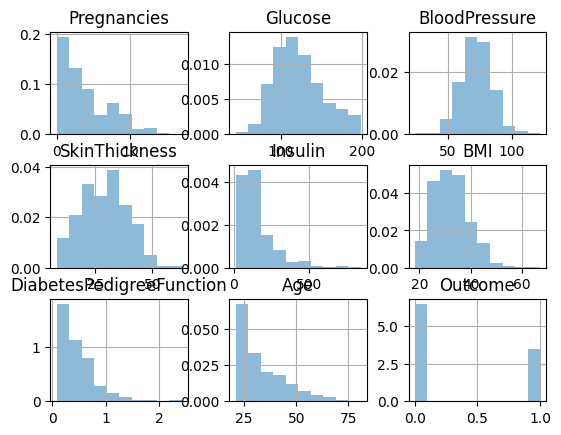

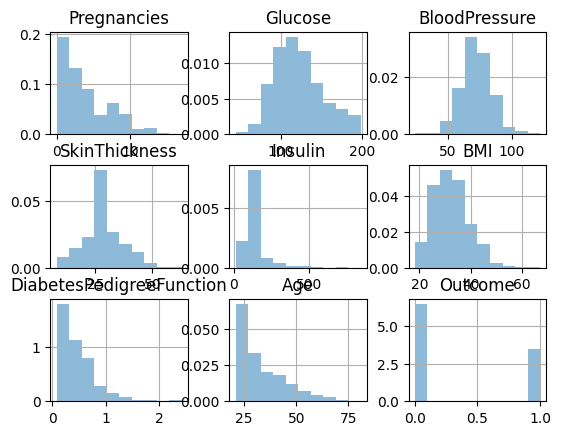

In [ ]:
#Compare variable distribution before and after imputing cols. Is there any clear difference?
df.hist(alpha=0.5, density=True)
df_simple.hist(alpha=0.5, density=True)
plt.show()

#Really distorted distribution in insulin and SkinThicknessVarible

## Iterative Imputation

* Create a copy of the df and use IterativeImputer to impute missing data
* Compare variable distribution before and after imputing cols. Is there any clear difference?

In [28]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=10, random_state=42)
Imputator = IterativeImputer(estimator=rf, random_state=0)
df_iterative = df.copy()
Imputator.fit(df_iterative[features])
df_iterative[features] = Imputator.transform(df_iterative[features])

/Users/chad/Desktop/Documenti/Uni/4_Anno/Big_Data_Analytics/BigData/EDA3/venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


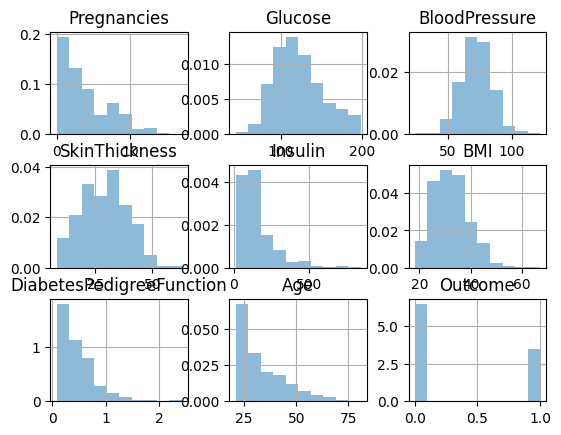

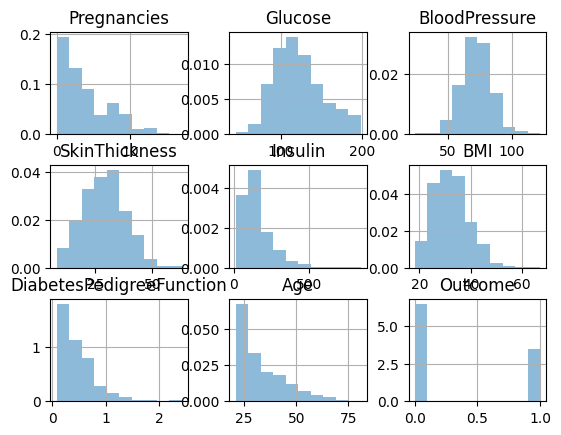

In [ ]:
df.hist(alpha=0.5, density=True)
df_iterative.hist(alpha=0.5, density=True)
plt.show()

#Little evidences of distrortion in Isnulin variable and SkinThickness Variable

## kNN imputer

* Create a copy of the df and use kNN imputation on  missing data.
* How many k? Usually not more than 5. 

In [31]:
from sklearn.impute import KNNImputer
df_knn = df.copy()
imputer = KNNImputer(n_neighbors=5)
imputer.fit(df_knn[features])
df_knn[features] = imputer.transform(df_knn[features])

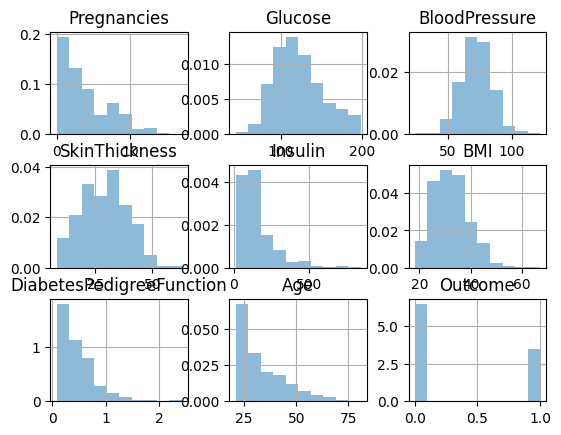

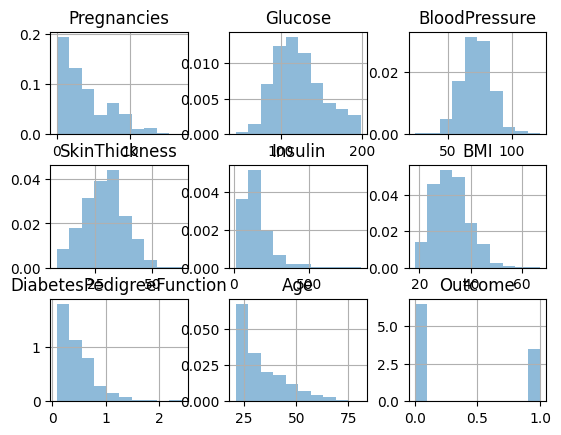

In [ ]:
df.hist(alpha=0.5, density=True)
df_knn.hist(alpha=0.5, density=True)
plt.show()

#Same way as before, evidences of distortion in Insulind and SkinThicknessVariable

### Compare missing value deletion and imputation methods.

* As the outcome we want to predict is binary, the simplest method we can use is logistic regression (from sklearn).

* Given the results obtained what is the best imputation method?
* Can you think about some other methods to estimate what was the best approach used? Think about correlation/distribution distance.


### Finally, assuming there is no MNAR happening here, can you guess whether data are MCAR or MAR?

Just by looking at the various distribution we plotted along the file, we can tell that deletion method may cause a distorion (even if not so big) of the distribution. This is causeb by the fact that we are actually dropping rows of the dataset, reducing its dimensionality and losing information. 
On the other hand, imputation methods are able to fill the missing data, thus keeping the same number of rows and preserving the original distribution.
The simple imputation method is the "worst" one, as filling the missing values with the mean of that column causes a lot of distortion. Meanwhile other two, Knn and Iterative are able to preserve the distribution with a little bit of distortion.

In [38]:

# fit a model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# collect all the training sets created above
training_df_dict={
    'drop': df_drop, 
    'SimpleImputer': df_simple,
    'IterativeImputer': df_iterative,
    'kNNImputer':df_knn 
}

# Scale test set features with the same scaler used for training
scaled_test_df=df_test.copy()
scaled_test_df[features] = scaler.transform(scaled_test_df[features])

# fit a logistic regression model on each training set obtained with different imputation techniques
for method in training_df_dict.keys():
  training_df=training_df_dict[method]
  X_train = training_df[features]
  model = LogisticRegression(solver='lbfgs')

  model.fit(X_train, training_df[target])
  # predict binary outcomes on the rescaled test set
  y_pred = model.predict(scaled_test_df[features])
  print(classification_report(df_test[target], y_pred))

              precision    recall  f1-score   support

           0       0.65      1.00      0.79        75
           1       0.00      0.00      0.00        40

    accuracy                           0.65       115
   macro avg       0.33      0.50      0.39       115
weighted avg       0.43      0.65      0.51       115

              precision    recall  f1-score   support

           0       0.65      1.00      0.79        75
           1       0.00      0.00      0.00        40

    accuracy                           0.65       115
   macro avg       0.33      0.50      0.39       115
weighted avg       0.43      0.65      0.51       115

              precision    recall  f1-score   support

           0       0.65      1.00      0.79        75
           1       0.00      0.00      0.00        40

    accuracy                           0.65       115
   macro avg       0.33      0.50      0.39       115
weighted avg       0.43      0.65      0.51       115

              preci

/Users/chad/Desktop/Documenti/Uni/4_Anno/Big_Data_Analytics/BigData/EDA3/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/chad/Desktop/Documenti/Uni/4_Anno/Big_Data_Analytics/BigData/EDA3/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{met